# Part 0 - Loads and Helper Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterSampler

from sklearn.metrics import ndcg_score

from pathlib import Path
from datetime import datetime

## Global Configurations

In [2]:
# Reproducibility
SEED = 42

# Paths
TRAIN_PATH = "../data/training_set_VU_DM.csv"
TEST_PATH = "../data/test_set_VU_DM.csv"

# Target engineering
BOOKING_RELEVANCE = 5
CLICK_RELEVANCE = 1
TARGET_COL = "target"

# Validation split
TEST_SIZE = 0.2

# Ranking evaluation
NDCG_AT = 5


# Columns to remove from features
LEAKAGE_COLS = [
    "target",
    "booking_bool",
    "click_bool",
    "gross_bookings_usd",
    "position",
]

ID_COLS = [
    "srch_id",
    "site_id",
    "visitor_location_country_id",
    "prop_country_id",
    "prop_id",
    "srch_destination_id",
]

DATE_COLS = [
    "date_time",
    "date",
]

DROP_COLS = LEAKAGE_COLS + ID_COLS + DATE_COLS

## Defining Columns and Data Types

In [4]:
cont_cols = [
    'visitor_hist_starrating',
    'visitor_hist_adr_usd',
    'prop_review_score',
    'prop_location_score1',
    'prop_location_score2',
    'prop_log_historical_price',
    'price_usd',
    'srch_query_affinity_score',
    'orig_destination_distance',
    'gross_bookings_usd',
    'comp1_rate_percent_diff',
    'comp2_rate_percent_diff',
    'comp3_rate_percent_diff',
    'comp4_rate_percent_diff',
    'comp5_rate_percent_diff',
    'comp6_rate_percent_diff',
    'comp7_rate_percent_diff',
    'comp8_rate_percent_diff'
]

bool_cols = [
    'prop_brand_bool',
    'promotion_flag',
    'srch_saturday_night_bool',
    'random_bool',
    'click_bool',
    'booking_bool'
]

id_cols = [
    'srch_id',
    'site_id',
    'visitor_location_country_id',
    'prop_country_id',
    'prop_id',
    'srch_destination_id'
]

cat_cols = [
    'comp1_rate', 'comp1_inv',
    'comp2_rate', 'comp2_inv',
    'comp3_rate', 'comp3_inv',
    'comp4_rate', 'comp4_inv',
    'comp5_rate', 'comp5_inv',
    'comp6_rate', 'comp6_inv',
    'comp7_rate', 'comp7_inv',
    'comp8_rate', 'comp8_inv'
]

int_cols = [
    'prop_starrating',
    'position',
    'srch_length_of_stay',
    'srch_booking_window',
    'srch_adults_count',
    'srch_children_count',
    'srch_room_count'
]

In [5]:
dtype_dict = {}

# float columns
for col in cont_cols:
    dtype_dict[col] = 'float32'

# bool columns
for col in bool_cols:
    dtype_dict[col] = 'bool'

# id columns
for col in id_cols:
    dtype_dict[col] = 'int32'

# categorical columns
for col in cat_cols:
    dtype_dict[col] = 'int8'

# small integer columns
for col in int_cols:
    dtype_dict[col] = 'int8'

## Helper Functions

### Loading

In [6]:
# Load Training Data
def load_train_data(
    path,
    booking_relevance=5,
    click_relevance=1
):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    # Create Target
    df["target"] = (
        booking_relevance * df["booking_bool"].astype("int8") +
        click_relevance * df["click_bool"].astype("int8")
    ).astype("int8")

    return df

In [7]:
# Load Testing Data
def load_test_data(path):

    df = pd.read_csv(
        path,
        dtype=dtype_dict,
        low_memory=True
    )

    return df

### Preprocessing

In [8]:
# Stateless Prepocess Function (applied before Train-Val split)
def stateless_preprocess(
    df,
    comp_rate_diff_upper_limit=150
):

    df = df.copy()

    # ==================================================
    # DATE PARSING
    # ==================================================

    df["date_time"] = pd.to_datetime(df["date_time"])

    # ==================================================
    # WRONG VALUE HANDLING
    # ==================================================

    # Negative booking windows are invalid
    df["booking_window_was_negative"] = (
        df["srch_booking_window"] < 0
    )

    df["srch_booking_window"] = (
        df["srch_booking_window"]
        .clip(lower=0)
    )

    # ==================================================
    # OUTLIER CAPPING
    # ==================================================

    # Cap extreme competitor rate differences
    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .clip(upper=comp_rate_diff_upper_limit)
        )

    # ==================================================
    # SEMANTIC MISSING VALUES -> NaN
    # ==================================================

    # Unknown starrating
    df["prop_starrating"] = (
        df["prop_starrating"]
        .replace(0, np.nan)
    )

    # Unknown historical price
    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .replace(0, np.nan)
    )

    # Unknown review score
    df["prop_review_score"] = (
        df["prop_review_score"]
        .replace(0, np.nan)
    )

    # ==================================================
    # MISSING VALUE FLAG FEATURES
    # ==================================================

    # Missing starrating
    df["no_starrating"] = (
        df["prop_starrating"].isna()
    )

    # Missing historical price
    df["prop_no_sold"] = (
        df["prop_log_historical_price"].isna()
    )

    # Missing review score
    df["no_review"] = (
        df["prop_review_score"].isna()
    )

    # Missing distance
    df["missing_distance"] = (
        df["orig_destination_distance"].isna()
    )

    # Missing affinity score
    df["no_affinity"] = (
        df["srch_query_affinity_score"].isna()
    )

    # Missing visitor history
    df["no_vis_hist"] = (
        df["visitor_hist_starrating"].isna()
    )

    # ==================================================
    # COMPETITOR AVAILABILITY FLAGS
    # ==================================================

    for i in range(1, 9):

        diff_col = f"comp{i}_rate_percent_diff"

        df[f"has_comp{i}_diff"] = (
            df[diff_col].notna()
        )

    # ==================================================
    # COMPETITOR CATEGORICAL MISSING VALUES
    # ==================================================

    # Missing competitor info gets explicit category
    for i in range(1, 9):

        rate_col = f"comp{i}_rate"
        inv_col = f"comp{i}_inv"

        df[rate_col] = (
            df[rate_col]
            .astype("float32")
            .fillna(99)
            .astype("category")
        )

        df[inv_col] = (
            df[inv_col]
            .astype("float32")
            .fillna(99)
            .astype("category")
        )

    return df

In [9]:
# ==================================================
# FIT FUNCTION
# Get global statistics from TRAIN set only
# ==================================================

def fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995
):

    stats = {}

    # ==================================================
    # PRICE USD QUANTILE CAP
    # ==================================================

    stats["price_usd_upper_cap"] = (
        train_df["price_usd"]
        .quantile(price_usd_quantile)
    )

    # ==================================================
    # PROP STARRATING
    # ==================================================

    stats["prop_starrating_mode"] = (
        train_df["prop_starrating"]
        .mode()[0]
    )

    # ==================================================
    # PROP LOG HISTORICAL PRICE
    # ==================================================

    stats["prop_log_historical_price_median"] = (
        train_df["prop_log_historical_price"]
        .median()
    )

    # ==================================================
    # PROP REVIEW SCORE
    # ==================================================

    stats["prop_review_score_hotel_medians"] = (
        train_df
        .groupby(
            "prop_id",
            observed=True
        )["prop_review_score"]
        .median()
    )

    stats["prop_review_score_global_median"] = (
        train_df["prop_review_score"]
        .median()
    )

    # ==================================================
    # PROP LOCATION SCORE 2
    # ==================================================

    stats["prop_location_score2_hotel_medians"] = (
        train_df
        .groupby(
            "prop_id",
            observed=True
        )["prop_location_score2"]
        .median()
    )

    stats["prop_location_score2_global_median"] = (
        train_df["prop_location_score2"]
        .median()
    )

    # ==================================================
    # ORIG DESTINATION DISTANCE
    # ==================================================

    stats["orig_destination_distance_median"] = (
        train_df["orig_destination_distance"]
        .median()
    )

    # ==================================================
    # SEARCH QUERY AFFINITY SCORE
    # ==================================================

    stats["srch_query_affinity_score_median"] = (
        train_df["srch_query_affinity_score"]
        .median()
    )

    # ==================================================
    # VISITOR HISTORY FEATURES
    # ==================================================

    stats["visitor_hist_starrating_median"] = (
        train_df["visitor_hist_starrating"]
        .median()
    )

    stats["visitor_hist_adr_usd_median"] = (
        train_df["visitor_hist_adr_usd"]
        .median()
    )

    # ==================================================
    # COMP RATE PERCENT DIFF FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        stats[f"{col}_median"] = (
            train_df[col]
            .median()
        )

    return stats

In [10]:
# ==================================================
# APPLY LEARNED PREPROCESSING
# Applied to TRAIN / VAL / TEST
# ==================================================

def apply_learned_preprocessing(
    df,
    stats
):

    df = df.copy()

    # ==================================================
    # PRICE USD
    # ==================================================

    df["price_usd"] = (
        df["price_usd"]
        .clip(upper=stats["price_usd_upper_cap"])
        .astype("float32")
    )

    # ==================================================
    # OPTIONAL LOG PRICE FEATURE
    # ==================================================

    df["price_usd_log"] = (
        np.log1p(df["price_usd"])
        .astype("float32")
    )

    # ==================================================
    # PROP STARRATING
    # ==================================================

    df["prop_starrating"] = (
        df["prop_starrating"]
        .fillna(stats["prop_starrating_mode"])
        .astype("int8")
    )

    # ==================================================
    # PROP LOG HISTORICAL PRICE
    # ==================================================

    df["prop_log_historical_price"] = (
        df["prop_log_historical_price"]
        .fillna(
            stats["prop_log_historical_price_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # PROP REVIEW SCORE
    # ==================================================

    hotel_review_medians = (
        df["prop_id"]
        .map(
            stats["prop_review_score_hotel_medians"]
        )
    )

    df["prop_review_score"] = (
        df["prop_review_score"]
        .fillna(hotel_review_medians)
        .fillna(
            stats["prop_review_score_global_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # PROP LOCATION SCORE 2
    # ==================================================

    hotel_location_medians = (
        df["prop_id"]
        .map(
            stats[
                "prop_location_score2_hotel_medians"
            ]
        )
    )

    df["prop_location_score2"] = (
        df["prop_location_score2"]
        .fillna(hotel_location_medians)
        .fillna(
            stats[
                "prop_location_score2_global_median"
            ]
        )
        .astype("float32")
    )

    # ==================================================
    # ORIG DESTINATION DISTANCE
    # ==================================================

    df["orig_destination_distance"] = (
        df["orig_destination_distance"]
        .fillna(
            stats["orig_destination_distance_median"]
        )
        .astype("float32")
    )

    df["orig_destination_distance_log"] = (
        np.log1p(df["orig_destination_distance"])
        .astype("float32")
    )

    # ==================================================
    # SEARCH QUERY AFFINITY SCORE
    # ==================================================

    df["srch_query_affinity_score"] = (
        df["srch_query_affinity_score"]
        .fillna(
            stats["srch_query_affinity_score_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # VISITOR HISTORY FEATURES
    # ==================================================

    df["visitor_hist_starrating"] = (
        df["visitor_hist_starrating"]
        .fillna(
            stats["visitor_hist_starrating_median"]
        )
        .astype("float32")
    )

    df["visitor_hist_adr_usd"] = (
        df["visitor_hist_adr_usd"]
        .fillna(
            stats["visitor_hist_adr_usd_median"]
        )
        .astype("float32")
    )

    # ==================================================
    # COMP RATE PERCENT DIFF FEATURES
    # ==================================================

    for i in range(1, 9):

        col = f"comp{i}_rate_percent_diff"

        df[col] = (
            df[col]
            .fillna(stats[f"{col}_median"])
            .astype("float32")
        )

    return df

### Train-Validation Split

In [11]:
# Train-Val Split Function
def train_val_split(
    df,
    group_col="srch_id",
    test_size=0.2,
    random_state=42
):

    splitter = GroupShuffleSplit(
        test_size=test_size,
        n_splits=1,
        random_state=random_state
    )

    train_idx, val_idx = next(
        splitter.split(
            df,
            groups=df[group_col]
        )
    )

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    return train_df, val_df

In [12]:
# ==================================================
# CONVERT CATEGORICAL COLUMNS TO INTEGER CODES
# ==================================================

def encode_categorical_columns(df, cat_cols):

    df = df.copy()

    for col in cat_cols:

        if col in df.columns:

            df[col] = (
                df[col]
                .astype("category")
                .cat
                .codes
                .astype("int32")
            )

    return df

### Feature Engineering

### Modeling

In [19]:
# Create Ranking Groups function
def create_ranking_groups(
    df,
    group_col="srch_id"
):

    groups = (
        df
        .groupby(group_col, observed=True)
        .size()
        .to_numpy()
    )

    return groups

In [20]:
# Create Model Matrix Function
def create_model_matrix(
    df,
    drop_cols=DROP_COLS,
    target_col=TARGET_COL,
    has_target=True,
    return_metadata=False
):

    # ==================================================
    # COPY DATAFRAME
    # ==================================================

    df = df.copy()

    # ==================================================
    # OPTIONAL METADATA
    # ==================================================

    metadata = df[[
        "srch_id",
        "prop_id"
    ]].copy()

    # ==================================================
    # CREATE X
    # ==================================================

    X = df.drop(
        columns=drop_cols,
        errors="ignore"
    )

    # ==================================================
    # CONVERT CATEGORY COLUMNS FOR XGBOOST
    # ==================================================

    cat_cols = X.select_dtypes(include=["category"]).columns

    for col in cat_cols:

        X[col] = (
            X[col]
            .cat
            .codes
            .astype("int16")
        )

    # ==================================================
    # CREATE y
    # ==================================================

    if has_target:

        y = df[target_col].copy()

        if return_metadata:
            return X, y, metadata

        return X, y

    # ==================================================
    # TEST SET
    # ==================================================

    if return_metadata:
        return X, metadata

    return X

### Training

### Evaluation

In [22]:
# Evaluation Function
def evaluate_ndcg(
    model,
    X,
    y,
    df,
    group_col="srch_id",
    target_col="target",
    k=NDCG_AT
):

    # ==================================================
    # PREDICT
    # ==================================================

    preds = model.predict(X)

    # ==================================================
    # CREATE EVALUATION DATAFRAME
    # ==================================================

    eval_df = df[[group_col]].copy()

    eval_df[target_col] = y.values
    eval_df["pred_score"] = preds

    # ==================================================
    # SORT PREDICTIONS WITHIN GROUP
    # ==================================================

    eval_df = eval_df.sort_values(
        [group_col, "pred_score"],
        ascending=[True, False]
    )

    # ==================================================
    # COMPUTE NDCG@K
    # ==================================================

    ndcg_scores = []

    for _, group in eval_df.groupby(group_col):

        true_relevance = (
            group[target_col]
            .values
        )

        pred_scores = (
            group["pred_score"]
            .values
        )

        ndcg = ndcg_score(
            [true_relevance],
            [pred_scores],
            k=k
        )

        ndcg_scores.append(ndcg)

    mean_ndcg = np.mean(ndcg_scores)

    # ==================================================
    # PRINT RESULT
    # ==================================================

    print(f"NDCG@{k}: {mean_ndcg:.5f}")

    return mean_ndcg

In [23]:
# ==================================================
# EVALUATE PRECOMPUTED PREDICTIONS
# ==================================================

def evaluate_predictions_ndcg(
    predictions,
    y,
    df,
    group_col="srch_id",
    k=5
):

    eval_df = df[[group_col]].copy()

    eval_df["target"] = np.asarray(y)
    eval_df["prediction"] = np.asarray(predictions)

    ndcg_scores = []

    for _, group in eval_df.groupby(group_col):

        true_relevance = [group["target"].values]
        pred_scores = [group["prediction"].values]

        score = ndcg_score(
            true_relevance,
            pred_scores,
            k=k
        )

        ndcg_scores.append(score)

    return np.mean(ndcg_scores)

In [24]:
# =========================================================
# TOP-K BOOKING / CLICK RETRIEVAL EVALUATION
# =========================================================
def evaluate_topk_behavior(
    model,
    X,
    df,
    max_k=5
):

    eval_df = df.copy()

    # -----------------------------------------------------
    # Predictions
    # -----------------------------------------------------

    eval_df["prediction"] = model.predict(X)

    # Sort by prediction within search
    eval_df = (
        eval_df.sort_values(
            ["srch_id", "prediction"],
            ascending=[True, False]
        )
    )

    # Rank predictions
    eval_df["pred_rank"] = (
        eval_df.groupby("srch_id")
        .cumcount() + 1
    )

    # -----------------------------------------------------
    # BOOKING SEARCHES
    # -----------------------------------------------------

    booking_searches = (
        eval_df.groupby("srch_id")["booking_bool"]
        .sum()
    )

    booking_search_ids = (
        booking_searches[booking_searches > 0]
        .index
    )

    booking_df = (
        eval_df[
            eval_df["srch_id"].isin(booking_search_ids)
        ]
    )

    booking_topk = []

    for k in range(1, max_k + 1):

        topk_df = (
            booking_df[
                booking_df["pred_rank"] <= k
            ]
        )

        success = (
            topk_df.groupby("srch_id")["booking_bool"]
            .max()
            .mean()
        )

        booking_topk.append(success * 100)

    # -----------------------------------------------------
    # CLICK-ONLY SEARCHES
    # -----------------------------------------------------

    search_booking = (
        eval_df.groupby("srch_id")["booking_bool"]
        .sum()
    )

    click_search_ids = (
        search_booking[search_booking == 0]
        .index
    )

    click_df = (
        eval_df[
            eval_df["srch_id"].isin(click_search_ids)
        ]
    )

    click_topk = []

    for k in range(1, max_k + 1):

        topk_df = (
            click_df[
                click_df["pred_rank"] <= k
            ]
        )

        success = (
            topk_df.groupby("srch_id")["click_bool"]
            .max()
            .mean()
        )

        click_topk.append(success * 100)

    # -----------------------------------------------------
    # PLOTS
    # -----------------------------------------------------

    ks = np.arange(1, max_k + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Booking plot
    bars1 = axes[0].bar(ks, booking_topk)

    axes[0].set_title("Booked Hotel Retrieved in Top-K")
    axes[0].set_xlabel("K")
    axes[0].set_ylabel("Probability (%)")
    axes[0].set_xticks(ks)

    for bar, value in zip(bars1, booking_topk):

        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    # Click plot
    bars2 = axes[1].bar(ks, click_topk)

    axes[1].set_title("Clicked Hotel Retrieved in Top-K\n(No Booking Searches)")
    axes[1].set_xlabel("K")
    axes[1].set_ylabel("Probability (%)")
    axes[1].set_xticks(ks)

    for bar, value in zip(bars2, click_topk):

        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

## Load Datasets

In [25]:
#  ========== Load Training Data ==========
train_df = load_train_data(
    TRAIN_PATH,
    booking_relevance=5,
    click_relevance=2
)
print(f"Shape of training set: {train_df.shape}")
train_df.dtypes

Shape of training set: (4958347, 55)


srch_id                           int32
date_time                        object
site_id                           int32
visitor_location_country_id       int32
visitor_hist_starrating         float32
visitor_hist_adr_usd            float32
prop_country_id                   int32
prop_id                           int32
prop_starrating                    int8
prop_review_score               float32
prop_brand_bool                    bool
prop_location_score1            float32
prop_location_score2            float32
prop_log_historical_price       float32
position                           int8
price_usd                       float32
promotion_flag                     bool
srch_destination_id               int32
srch_length_of_stay                int8
srch_booking_window                int8
srch_adults_count                  int8
srch_children_count                int8
srch_room_count                    int8
srch_saturday_night_bool           bool
srch_query_affinity_score       float32


# Part 1 - Preprocessing for Train, Validation, Test Sets

In [26]:
# ==================================================
# STATELESS PREPROCESSING
# ==================================================

train_df = stateless_preprocess(train_df)

# ==================================================
# TRAIN / VALIDATION SPLIT
# ==================================================

train_df, val_df = train_val_split(
    train_df,
    group_col="srch_id",
    test_size=TEST_SIZE,
    random_state=SEED
)

# ==================================================
# Handle Categorical Data
# ==================================================

train_df = encode_categorical_columns(train_df, cat_cols)
val_df = encode_categorical_columns(val_df, cat_cols)

# ==================================================
# FIT LEARNED PREPROCESSING
# ==================================================

preprocessing_stats = fit_learned_preprocessing(
    train_df,
    price_usd_quantile=0.995
)

# ==================================================
# APPLY LEARNED PREPROCESSING
# ==================================================

train_df = apply_learned_preprocessing(
    train_df,
    preprocessing_stats
)

val_df = apply_learned_preprocessing(
    val_df,
    preprocessing_stats
)




### Verifying Preprocessing

In [27]:
# ==================================================
# VERIFY SHAPES
# ==================================================

print("========== SHAPES ==========")

print(f"Train shape:      {train_df.shape}")
print(f"Validation shape: {val_df.shape}")

# ==================================================
# VERIFY REMAINING MISSING VALUES
# ==================================================

print("\n========== TRAIN NaNs ==========")

train_nans = (
    train_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(train_nans[train_nans > 0])

print("\n========== VALIDATION NaNs ==========")

val_nans = (
    val_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(val_nans[val_nans > 0])

========== SHAPES ==========
Train shape:      (3966682, 105)
Validation shape: (991665, 105)

========== TRAIN NaNs ==========
gross_bookings_usd    3855821
dtype: int64

========== VALIDATION NaNs ==========
gross_bookings_usd    964136
dtype: int64


# Part 2 - Modeling

### 2.1 Preparation

In [28]:
# ==================================================
# SORT DATA FOR RANKING MODELS
# ==================================================

train_df = (
    train_df
    .sort_values("srch_id")
    .reset_index(drop=True)
)

val_df = (
    val_df
    .sort_values("srch_id")
    .reset_index(drop=True)
)


# ==================================================
# CREATE RANKING GROUPS
# ==================================================

train_groups = create_ranking_groups(train_df)
val_groups = create_ranking_groups(val_df)

# ==================================================
# CREATE MODEL MATRICES
# ==================================================

X_train, y_train = create_model_matrix(
    train_df,
    has_target=True
)

X_val, y_val = create_model_matrix(
    val_df,
    has_target=True
)

# ==================================================
# VERIFY GROUP CONSISTENCY
# ==================================================

print("========== GROUP CHECK ==========")

print(train_groups.sum(), len(X_train))
print(val_groups.sum(), len(X_val))


========== GROUP CHECK ==========
3966682 3966682
991665 991665


### 2.2 Training

In [29]:
# ==================================================
# TRAIN SVD Model
# ==================================================




Training LambdaMART...


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 10083
[LightGBM] [Info] Number of data points i

### 2.3 Evaluation

In [31]:
# =========================================================
# EVALUATION ON TRAIN
# =========================================================

train_ndcg5 = evaluate_ndcg(
    model=lgb_ranker,
    X=X_train,
    y=y_train,
    df=train_df,
    group_col="srch_id",
    target_col=TARGET_COL,
    k=NDCG_AT
)

print(f"Train NDCG@5: {train_ndcg5:.5f}")


# =========================================================
# EVALUATION ON VALIDATION
# =========================================================

val_ndcg5 = evaluate_ndcg(
    model=lgb_ranker,
    X=X_val,
    y=y_val,
    df=val_df,
    group_col="srch_id",
    target_col=TARGET_COL,
    k=NDCG_AT
)

print(f"Validation NDCG@5: {val_ndcg5:.5f}")

C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
NDCG@5: 0.51196
Train NDCG@5: 0.51196


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
NDCG@5: 0.39884
Validation NDCG@5: 0.39884


C:\Users\gerib\anaconda3\envs\recsys\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


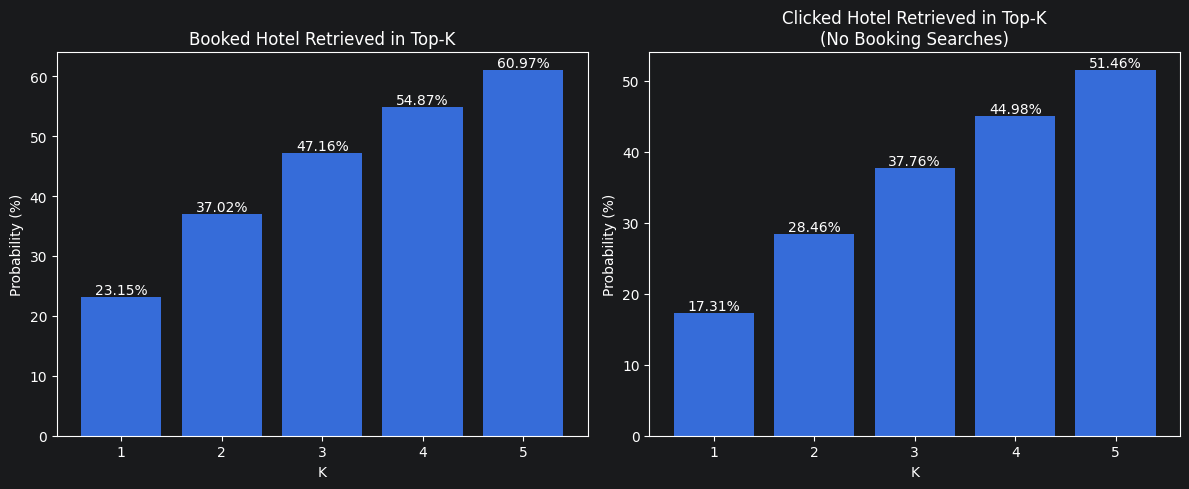

In [32]:
# =========================================================
# EVALUATION of TopK Behavior
# =========================================================

evaluate_topk_behavior(
    model=lgb_ranker,
    X=X_val,
    df=val_df
)

### Feature Importance

                              feature  split_importance  gain_importance
90                 price_vs_prop_mean              4016    411993.646889
79            location_vs_search_mean              4201    301166.615317
69                  prop_avg_position              4388    264794.620798
6                prop_location_score2              4726    237773.027635
87          price_vs_historical_price              4141    173261.045464
84                    value_for_money              3873    166012.234093
80          star_percentile_in_search              4321    163142.324616
61                  prop_booking_rate              3137    150657.384733
5                prop_location_score1              4054    148015.710248
60                           prop_ctr              2830    117455.136638
85          cheap_popular_interaction              2161    110774.576530
62                   prop_impressions              4275    110662.298885
92              ctr_price_interaction              

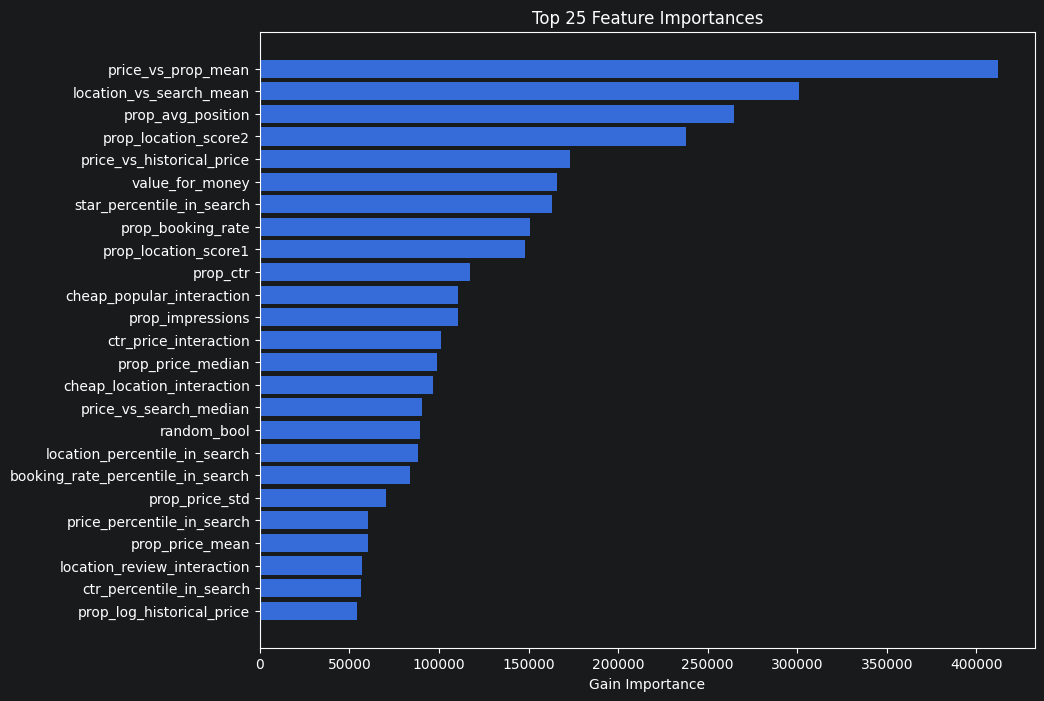

In [33]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

feature_importance_df = pd.DataFrame({

    "feature": X_train.columns,

    # Split importance
    "split_importance": (
        lgb_ranker.feature_importances_
    ),

    # Gain importance
    "gain_importance": (
        lgb_ranker.booster_
        .feature_importance(
            importance_type="gain"
        )
    )
})

# ---------------------------------------------------------
# Sort by gain importance
# ---------------------------------------------------------

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "gain_importance",
        ascending=False
    )
)

# ---------------------------------------------------------
# Print table
# ---------------------------------------------------------

print(
    feature_importance_df.head(30)
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------


top_n = 25

plot_df = (
    feature_importance_df
    .head(top_n)
    .sort_values("gain_importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["feature"],
    plot_df["gain_importance"]
)

plt.xlabel("Gain Importance")
plt.title(f"Top {top_n} Feature Importances")

plt.show()